In [3]:
# Insurance Claim Amount Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\H.T\Desktop\remote internships\DevelopersHub Corporation\Task 4\insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
## 2. Data Exploration

print(df.shape)
print(df.info())
print(df.isnull().sum())

In [ ]:
## 3. Encoding Categorical Features

df['sex'] = df['sex'].map({'female': 0, 'male': 1})
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

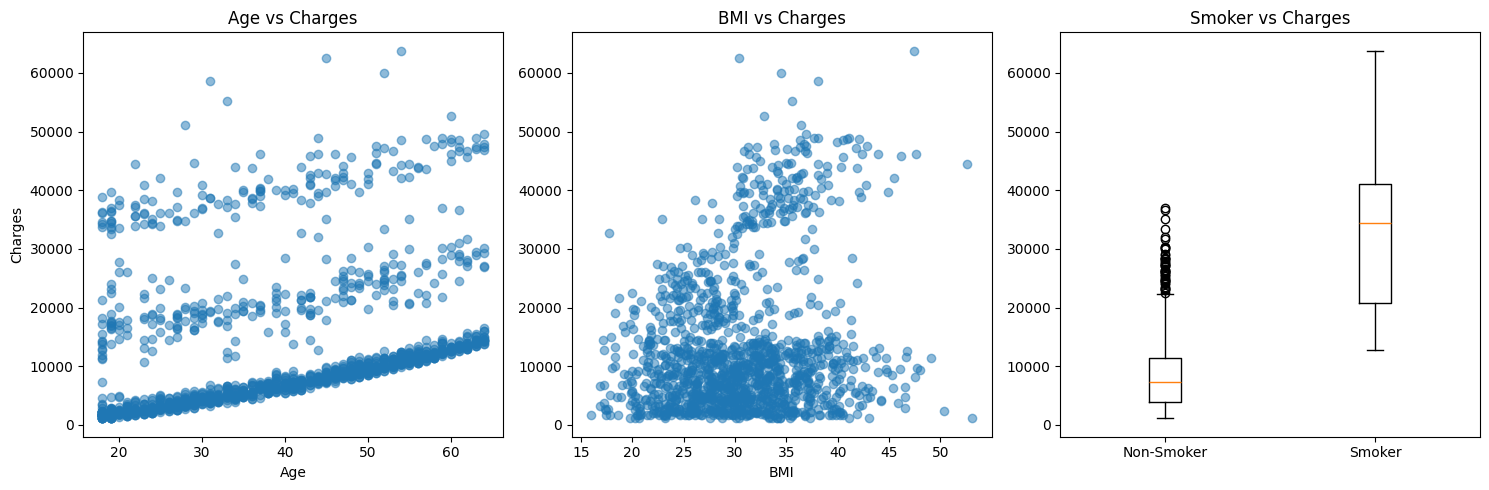

In [6]:
## 4. Visualization


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Age vs Charges
axes[0].scatter(df['age'], df['charges'], alpha=0.5)
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')

# BMI vs Charges
axes[1].scatter(df['bmi'], df['charges'], alpha=0.5)
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')

# Smoker vs Charges
axes[2].boxplot([df[df['smoker']==0]['charges'], df[df['smoker']==1]['charges']])
axes[2].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[2].set_title('Smoker vs Charges')

plt.tight_layout()
plt.savefig('visualization.png')
plt.show()

In [7]:
## 5. Model Training

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [8]:
## 6. Model Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 4181.19
RMSE: 5796.28


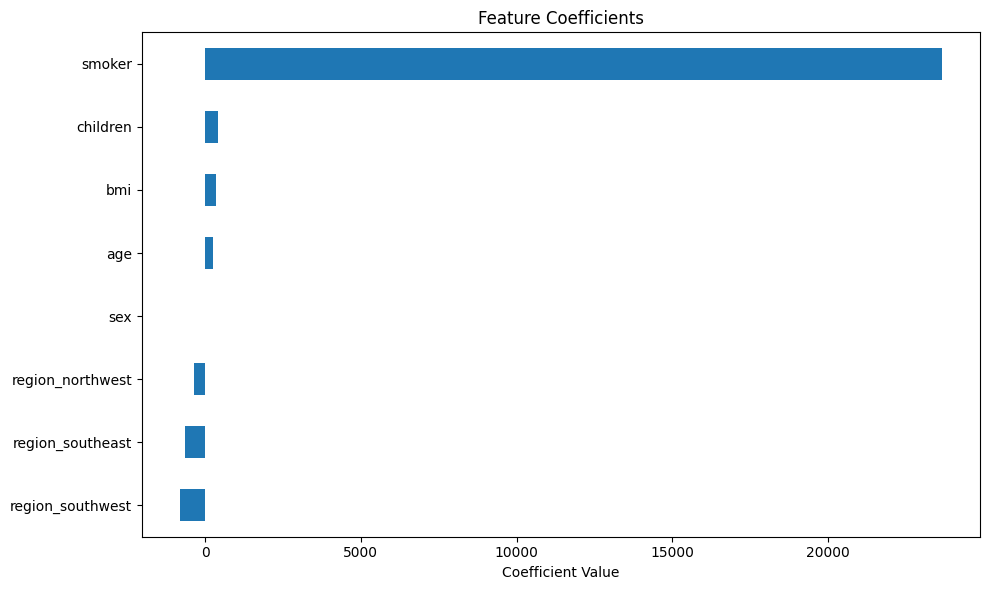

In [9]:
## 7. Feature Importance (Coefficients)

coefficients = pd.Series(model.coef_, index=X.columns)
coefficients.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('feature_coefficients.png')
plt.show()